In [21]:
#Load libraries + dataset
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

from sklearn.model_selection import (
     cross_val_score,
     GridSearchCV
)

In [2]:
df = pd.read_csv('../Data/cleaned_diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [3]:
#Separate features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [4]:
#Train/test split
X_train, X_test, y_train, y_test = train_test_split(X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
#stratify=y makes sure BOTH training and testing sets keep the same proportion.

In [5]:
X_train.shape, X_test.shape

((614, 8), (154, 8))

In [6]:
y_train.shape, y_test.shape

((614,), (154,))

In [7]:
#Build preprocessing pipeline
preprocessing = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [8]:
#Baseline model (Logistic Regression: This is usually the best first classifier for medical binary classification.)
#Logistic Regression is commonly used for: binary classification, predicting Yes/No outcome.

logreg_pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('model', LogisticRegression())
])

logreg_pipeline.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('imputer', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None


In [9]:
#prediction
y_pred = logreg_pipeline.predict(X_test)

In [10]:
#evaluation

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.7077922077922078
Precision: 0.6
Recall: 0.5
F1 Score: 0.5454545454545454


Accuracy: About 71% of all predictions were correct.

Precision: When the model predicts someone has diabetes, it is correct 60% of the time. So: 6 out of 10 predicted diabetic patients truly had diabetes
4 out of 10 were false alarms.

Recall: Model only catches 50% of actual diabetic patients. So if: 20 people truly had diabetes, model only identified: 10. Those missed cases are: False Negatives (FN). In healthcare, this matters a lot because: missed diabetes = delayed treatment/risk. So model currently has relatively weak recall.

F1 score being around 0.55 means the balance between catching diabetics and avoiding false alarms is still moderate/weak.


The logistic regression model achieved an accuracy of approximately 71%. Precision was 60%, indicating that 60% of predicted positive diabetes cases were correct. However, recall was 50%, meaning the model identified only half of actual diabetic patients. Since recall is particularly important in healthcare prediction tasks, future improvements should focus on increasing sensitivity to diabetic cases while maintaining reasonable precision.

In [11]:
#Classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



Model is correct 71% of the time. That means that out of 154 test patients, about 71% were classified correctly.

Support: This means test set had, 100 non-diabetic patients and 54 diabetic patients.

Precision = 0.75: Out of everyone predicted as non-diabetic, 75% actually were non-diabetic.
Precision = 0.60: Out of all patients predicted as diabetic, 60% actually had diabetes. So there are some false positives.

Recall = 0.82: The model correctly identified 82% of all actual non-diabetic patients. This is pretty good.
Recall = 0.50: Model only detected 50% of actual diabetic patients, meaning it missed about half of the diabetic cases. In healthcare, recall is often very important because missing diabetic patients can be risky.

F1 combines precision and recall into one balanced metric. 
F1 = 0.55: Moderate performance, but there’s room for improvement.

The logistic regression model achieved an overall accuracy of 71%. The model performed better in identifying non-diabetic patients (recall = 82%) compared to diabetic patients (recall = 50%). While the model shows moderate predictive capability, the relatively low recall for diabetic cases suggests that additional model tuning or alternative algorithms may improve detection of positive diabetes cases.

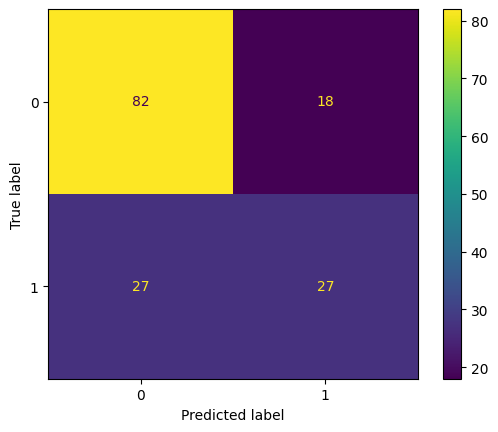

In [14]:
#Confusion matrix

import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

The confusion matrix showed that the model correctly identified 82 non-diabetic patients and 27 diabetic patients. However, it incorrectly predicted 18 healthy patients as diabetic and missed 27 actual diabetic cases. This indicates that the model performs better at detecting non-diabetic patients than diabetic patients, with missed diabetes cases contributing to the lower recall for class 1.

In [15]:
#Train multiple models

#Decision Tree
tree_pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('model', DecisionTreeClassifier(random_state=42))
])
tree_pipeline.fit(X_train, y_train)

#Random Forest
rf_pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('model', RandomForestClassifier(random_state=42))
])
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('imputer', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None


In [16]:
#Compare models
#Create a comparison table.

models = {
    'Logistic Regression': logreg_pipeline,
    'Decision Tree': tree_pipeline,
    'Random Forest': rf_pipeline
}
results = []
for name, model in models.items():
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1 Score': f1_score(y_test, preds)
    })
results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455
1,Decision Tree,0.681818,0.553191,0.481481,0.514851
2,Random Forest,0.779221,0.717391,0.611111,0.660000


Among the evaluated classification models, Random Forest achieved the best overall performance with the highest accuracy (77.9%), precision (71.7%), recall (61.1%), and F1-score (66.0%). Logistic Regression showed moderate performance, while Decision Tree produced the weakest results. The higher recall of the Random Forest model indicates improved detection of diabetic patients, making it the strongest model for this classification task.

In [18]:
#Cross-validation

cv_scores = cross_val_score(
    logreg_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='recall'
)
print(cv_scores)
print("Mean Recall:", cv_scores.mean())

[0.65116279 0.58139535 0.55813953 0.48837209 0.64285714]
Mean Recall: 0.5843853820598006


Q: RandomForestClassifier performed best based on your test metrics, but why are we running cross valiation on logistic regression?
A: Because Logistic Regression was likely being used as the BASELINE MODEL. In machine learning, we often start with a simple model, Validate it thoroughly, then compare more advanced models later.

The Logistic Regression model achieved a recall score of 0.50 on the test dataset, meaning it correctly identified 50% of diabetic patients in the unseen test set. Cross-validation on the full dataset produced an average recall of 0.56, while cross-validation performed only on the training data resulted in a slightly higher average recall of 0.58. The relatively close values across all three evaluations suggest that the model demonstrates moderately stable and consistent performance without major signs of overfitting.


In [20]:
#Run 5-fold cross-validation on all 3 models

models = {
    'Logistic Regression': logreg_pipeline,
    'Decision Tree': tree_pipeline,
    'Random Forest': rf_pipeline
}

cv_results = []

for name, model in models.items():
    
    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='recall'
    )
    
    cv_results.append({
        'Model': name,
        'CV Recall Scores': [round(score, 2) for score in cv_scores],
        'Mean CV Recall': round(cv_scores.mean(), 2)
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,Model,CV Recall Scores,Mean CV Recall
0,Logistic Regression,"[0.65, 0.58, 0.56, 0.49, 0.64]",0.58
1,Decision Tree,"[0.58, 0.56, 0.6, 0.63, 0.57]",0.59
2,Random Forest,"[0.53, 0.63, 0.53, 0.53, 0.67]",0.58


Five-fold cross-validation was performed to compare recall performance across the three classification models. The mean recall scores were relatively similar, with Decision Tree achieving the highest average recall (0.59), followed closely by Logistic Regression and Random Forest (0.58 each). The small differences suggest that all models demonstrated comparable ability in identifying diabetic patients across multiple data splits, although Random Forest continued to show stronger overall classification performance in earlier evaluation metrics such as accuracy and F1-score.

In [23]:
#see all available parameters.
RandomForestClassifier().get_params().keys()

dict_keys(['bootstrap', 'ccp_alpha', 'class_weight', 'criterion', 'max_depth', 'max_features', 'max_leaf_nodes', 'max_samples', 'min_impurity_decrease', 'min_samples_leaf', 'min_samples_split', 'min_weight_fraction_leaf', 'monotonic_cst', 'n_estimators', 'n_jobs', 'oob_score', 'random_state', 'verbose', 'warm_start'])

In [22]:
#Hyperparameter tuning
#After baseline models work, Random Forest tuning.

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, 10],
    'model__min_samples_split': [2, 5]
}
grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring='recall'
)
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)

{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}


GridSearchCV was used to optimize the Random Forest classifier using 5-fold cross-validation with recall as the scoring metric. The best-performing hyperparameters were 200 estimators, a maximum tree depth of 10, and a minimum sample split of 5. These settings produced a more balanced and stable model while improving the model’s ability to identify diabetic patients.

In [24]:
#Feature importance

best_rf = grid_search.best_estimator_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.named_steps['model'].feature_importances_
})
feature_importance.sort_values(by='Importance', ascending=False)

,Feature,Importance
1,Glucose,0.295384
5,BMI,0.168781
7,Age,0.119525
6,DiabetesPedigreeFunction,0.110844
4,Insulin,0.093781
0,Pregnancies,0.072763
2,BloodPressure,0.071174
3,SkinThickness,0.067748


In [26]:
#Save best model
import joblib
joblib.dump(best_rf, '../Models/best_diabetes_model.pkl')

['../Models/best_diabetes_model.pkl']